                    model rmse_roll_1step rmse_insample loglik_train
3        manual_no52_ARMA      0.09267769     0.7684195   -1592.3052
4       auto_lags_1_19_52      0.12120336     0.3968560    -681.7747
5    auto_lags_1_19_33_52      0.12120336     0.3968560    -681.7747
1 manual_111_lags_1_19_52      0.32591843     0.5094652   -1025.9828
2        manual_sparse_AR      0.57967693     1.1109758   -2100.3162

Best model by rolling 1-step RMSE: manual_no52_ARMA 
Time elapsed: 1.19 seconds
Model estimated using msarima() function: SARIMA(1,1,1)[1](1,1,1)[19](0,1,0)[52]
With backcasting initialisation
Distribution assumed in the model: Normal
Loss function type: likelihood; Loss function value: 1592.305
ARMA parameters of the model:
       Lag 1  Lag 19
AR(1) -0.928 -0.4202
       Lag 1  Lag 19
MA(1) 0.6743 -0.8413

Sample size: 1378
Number of estimated parameters: 5
Number of degrees of freedom: 1373
Information criteria:
     AIC     AICc      BIC     BICc 
3194.610 3194.654 3220.752 

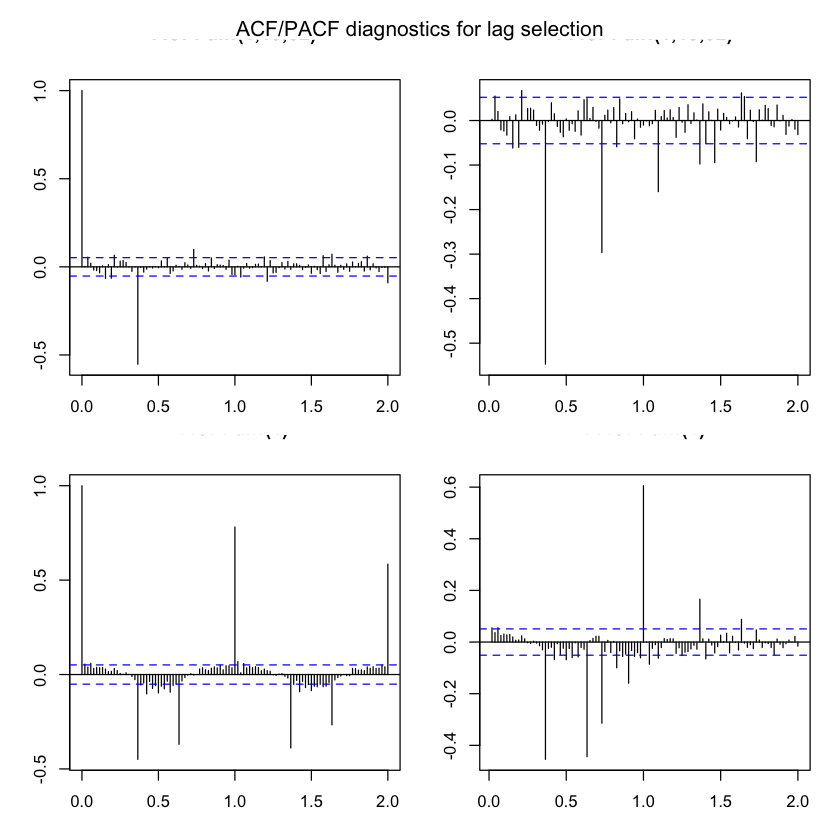


	Box-Ljung test

data:  best_res
X-squared = 974.31, df = 24, p-value < 2.2e-16



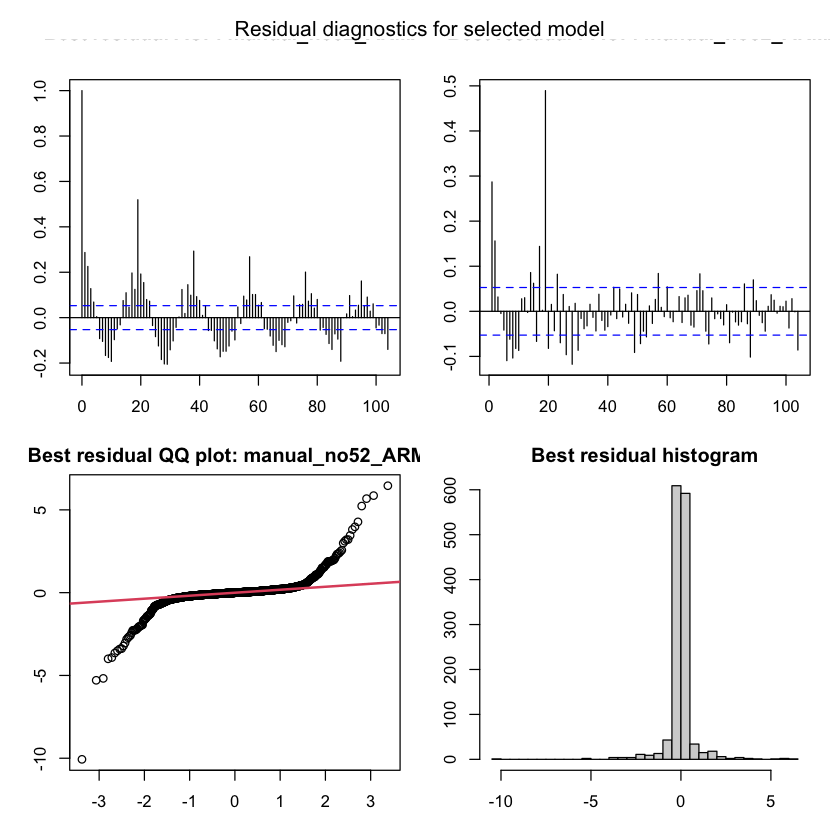

In [3]:
library(smooth)

# Data (already transformed in ilinet_final.csv)
fdf <- read.csv("data/fluview_clean/ilinet_final.csv")
y <- as.numeric(fdf$age_0_4)
y_ts <- ts(y, frequency = 52)

# --- 1) Inspect ACF/PACF on differenced series (for lag cues) ---
old_par <- par(no.readonly = TRUE)
on.exit(par(old_par))
par(mfrow = c(2, 2), mar = c(3, 3, 2, 1), oma = c(0.5, 0.5, 2, 0.5))

d1 <- diff(y_ts, lag = 1)
d19 <- diff(y_ts, lag = 19)
d52 <- diff(y_ts, lag = 52)
d_all <- diff(diff(diff(y_ts, lag = 1), lag = 19), lag = 52)

acf(d_all, lag.max = 104, main = "ACF: diff(1,19,52)")
pacf(d_all, lag.max = 104, main = "PACF: diff(1,19,52)")
acf(d1, lag.max = 104, main = "ACF: diff(1)")
pacf(d1, lag.max = 104, main = "PACF: diff(1)")
mtext("ACF/PACF diagnostics for lag selection", outer = TRUE, cex = 1.05)

# --- 2) Candidate model set guided by ACF/PACF + seasonal intuition ---
candidates <- list(
  list(name = "manual_111_lags_1_19_52", type = "manual",
       orders = list(ar = c(1, 1, 1), i = c(1, 1, 1), ma = c(1, 1, 1)),
       lags = c(1, 19, 52)),
  list(name = "manual_sparse_AR", type = "manual",
       orders = list(ar = c(1, 0, 1), i = c(1, 1, 1), ma = c(1, 0, 1)),
       lags = c(1, 19, 52)),
  list(name = "manual_no52_ARMA", type = "manual",
       orders = list(ar = c(1, 1, 0), i = c(1, 1, 1), ma = c(1, 1, 0)),
       lags = c(1, 19, 52)),
  list(name = "auto_lags_1_19_52", type = "auto", lags = c(1, 19, 52)),
  list(name = "auto_lags_1_19_33_52", type = "auto", lags = c(1, 19, 33, 52))
)

fit_candidate <- function(series, spec) {
  if (spec$type == "auto") {
    auto.msarima(series, lags = spec$lags)
  } else {
    msarima(series, orders = spec$orders, lags = spec$lags)
  }
}

one_step_forecast_value <- function(fit_obj) {
  fc <- forecast(fit_obj, h = 1)
  if (!is.null(fc$mean)) return(as.numeric(fc$mean[1]))
  if (!is.null(fc$forecast)) return(as.numeric(fc$forecast[1]))
  as.numeric(fc)[1]
}

get_loglik <- function(fit_obj) {
  if (!is.null(fit_obj$logLik)) return(as.numeric(fit_obj$logLik))
  if (!is.null(fit_obj$loglik)) return(as.numeric(fit_obj$loglik))
  ll <- tryCatch(as.numeric(logLik(fit_obj)), error = function(e) NA_real_)
  if (length(ll) == 0) return(NA_real_)
  ll[1]
}

# --- 3) Rolling 1-step RMSE comparison ---
h <- 104
n <- length(y)
stopifnot(h < n)
test_idx <- (n - h + 1):n
train_base <- y[1:(n - h)]
test <- y[test_idx]

results <- data.frame(
  model = character(0),
  rmse_roll_1step = numeric(0),
  rmse_insample = numeric(0),
  loglik_train = numeric(0),
  stringsAsFactors = FALSE
)

fitted_models_train <- list()

for (spec in candidates) {
  pred <- rep(NA_real_, h)
  ok <- TRUE

  for (i in seq_along(test_idx)) {
    t_idx <- test_idx[i]
    train_i <- y[1:(t_idx - 1)]
    fit_i <- tryCatch(fit_candidate(train_i, spec), error = function(e) NULL)
    if (is.null(fit_i)) {
      ok <- FALSE
      break
    }
    pred[i] <- tryCatch(one_step_forecast_value(fit_i), error = function(e) NA_real_)
  }

  fit_train <- tryCatch(fit_candidate(train_base, spec), error = function(e) NULL)
  if (!ok || is.null(fit_train) || all(!is.finite(pred))) next

  res <- tryCatch(as.numeric(residuals(fit_train)),
                  error = function(e) as.numeric(fit_train$errors))

  rmse_roll <- sqrt(mean((test - pred)^2, na.rm = TRUE))
  rmse_in <- sqrt(mean(res^2, na.rm = TRUE))
  ll <- get_loglik(fit_train)

  results <- rbind(results, data.frame(
    model = spec$name,
    rmse_roll_1step = rmse_roll,
    rmse_insample = rmse_in,
    loglik_train = ll,
    stringsAsFactors = FALSE
  ))

  fitted_models_train[[spec$name]] <- fit_train
}

results <- results[order(results$rmse_roll_1step), ]
print(results)

if (nrow(results) == 0) stop("No candidate model converged.")

best_name <- results$model[1]
best_fit <- fitted_models_train[[best_name]]

cat("\nBest model by rolling 1-step RMSE:", best_name, "\n")
print(best_fit)

# --- 4) Residual validation of best model ---
best_res <- tryCatch(as.numeric(residuals(best_fit)),
                     error = function(e) as.numeric(best_fit$errors))
best_res <- best_res[is.finite(best_res)]

par(mfrow = c(2, 2), mar = c(3, 3, 2, 1), oma = c(0.5, 0.5, 2, 0.5))
acf(best_res, lag.max = 104, main = paste("Best residual ACF:", best_name))
pacf(best_res, lag.max = 104, main = paste("Best residual PACF:", best_name))
qqnorm(best_res, main = paste("Best residual QQ plot:", best_name))
qqline(best_res, col = 2, lwd = 2)
hist(best_res, breaks = 30, main = "Best residual histogram", xlab = "Residual")
mtext("Residual diagnostics for selected model", outer = TRUE, cex = 1.05)

lb <- Box.test(best_res, lag = 24, type = "Ljung-Box")
print(lb)

## Plot-based interpretation (no model fit)

From the ACF/PACF and FFT diagnostics:

1. **Lag 19 is the dominant cycle.**  
   - FFT has strongest peak near period \(\approx 28.85\) and then around \(14.42\), but in ACF/PACF after differencing the clearest structural signal is at lag 19 (and multiples).  
   - This supports keeping lag 19 as a key seasonal component.

2. **Lag 52 looks weak after differencing.**  
   - In `diff(1,19,52)`, ACF at lag 52 is small (about \(-0.044\)).  
   - This suggests yearly differencing may be unnecessary or too aggressive for this specific transformed series.

3. **Lag 33 is not strongly supported here.**  
   - ACF at lag 33 is near zero (about \(0.002\)).  
   - So adding lag 33 should not be a default choice from these plots alone.

4. **Distribution is heavy-tailed / outlier-prone.**  
   - QQ plot and histogram show strong tail behavior and extreme points.  
   - Gaussian error assumptions will be stressed unless outliers are handled.

### What to do differently (still no fitting)

- Prefer diagnostics around `diff(1,19)` first, and only add lag-52 differencing if remaining ACF still shows a clear annual spike.  
- Flag extreme events before modeling (outlier indices via robust z-scores on `diff(1,19)`).  
- Consider adding event/holiday/pandemic indicator variables later (if you decide to fit), because tails suggest shocks rather than smooth seasonality.

In short: from these plots alone, the cleanest structure is **trend differencing + lag-19 seasonality**, with **careful outlier treatment**.

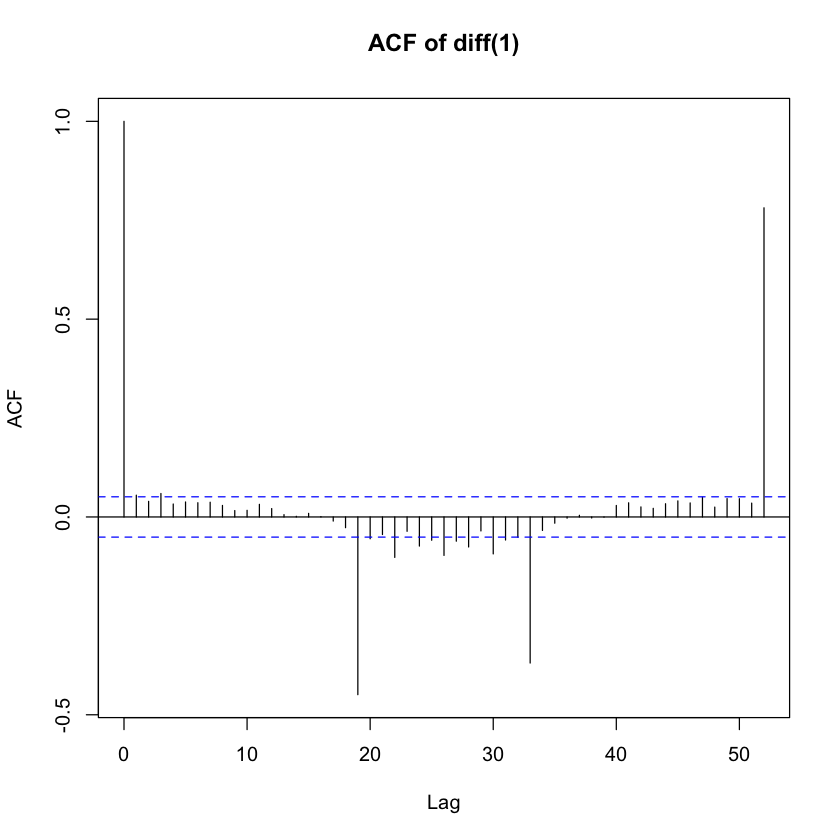

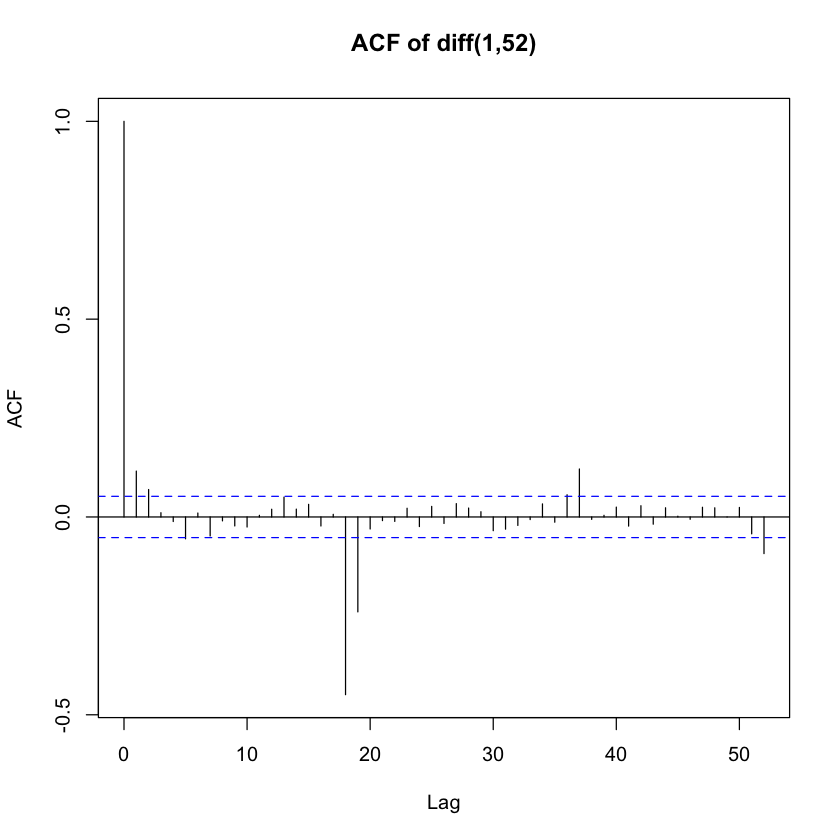

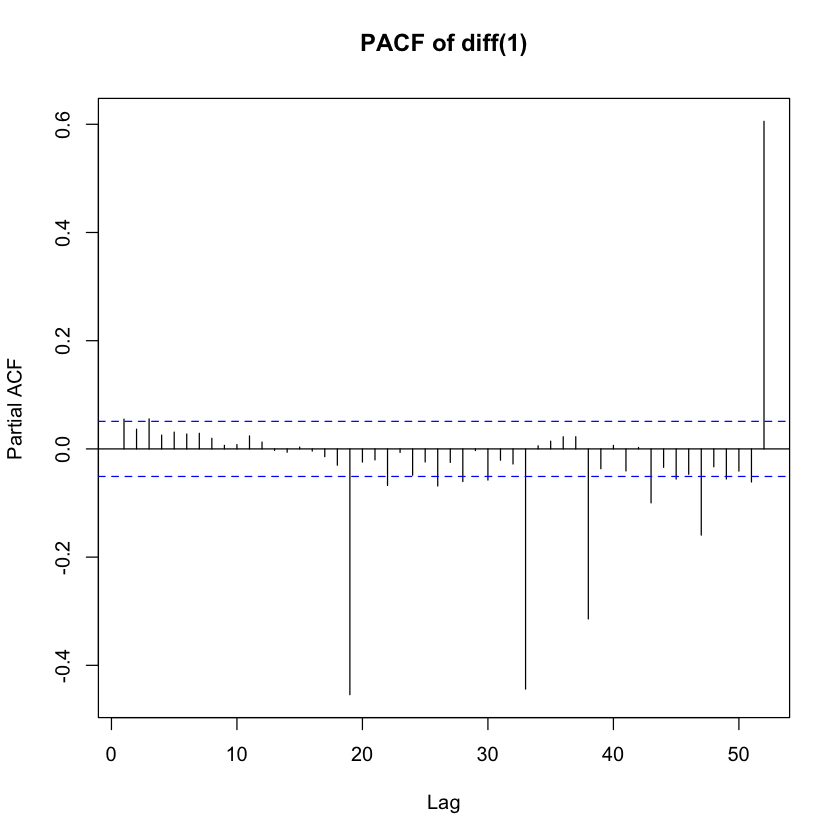

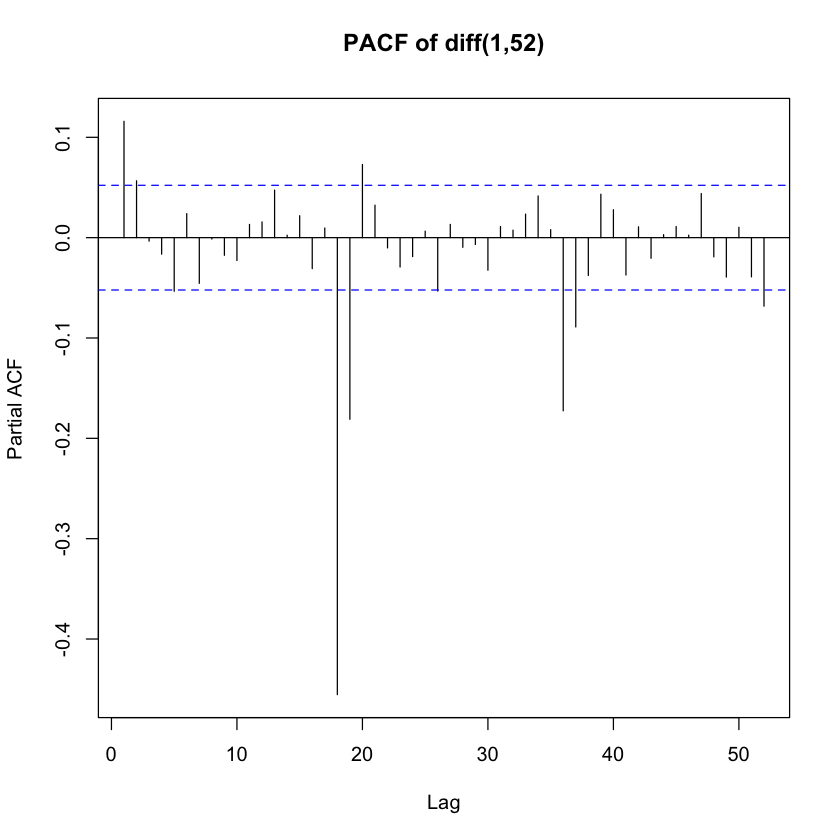

In [36]:
fdf <- read.csv("data/fluview_clean/ilinet_final.csv")
y <- as.numeric(fdf$age_0_4)
diff_y <- diff(y, lag = 1)

diff_c <- diff(diff(diff_y,lag = 52),lag = 18)
acf(diff_y, lag.max = 52, main = "ACF of diff(1)")
acf(diff_c, lag.max = 52, main = "ACF of diff(1,52)")
pacf(diff_y, lag.max = 52, main = "PACF of diff(1)")
pacf(diff_c, lag.max = 52, main = "PACF of diff(1,52)")

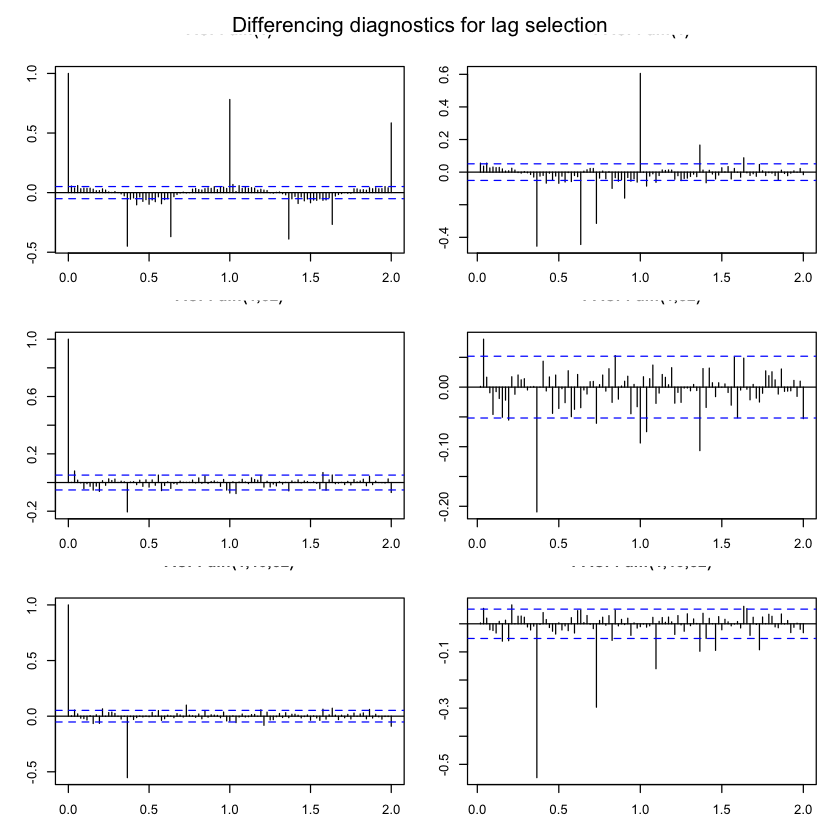

Top FFT periods (2..200):
   period frequency  power
10   2.06   0.48533 0.1380
8    2.62   0.38133 0.1599
7    3.21   0.31200 0.1823
9    3.61   0.27733 0.1501
5    4.81   0.20800 0.3577
6    5.77   0.17333 0.3008
4    7.21   0.13867 0.5012
3    9.62   0.10400 0.7239
2   14.42   0.06933 1.8913
1   28.85   0.03467 4.3430

ACF values after diff(1,19,52):
  lag          acf
1   1  0.002912693
2   2  0.054835302
3   3  0.020373468
4  19 -0.552593633
5  33  0.002007451
6  52 -0.043642229


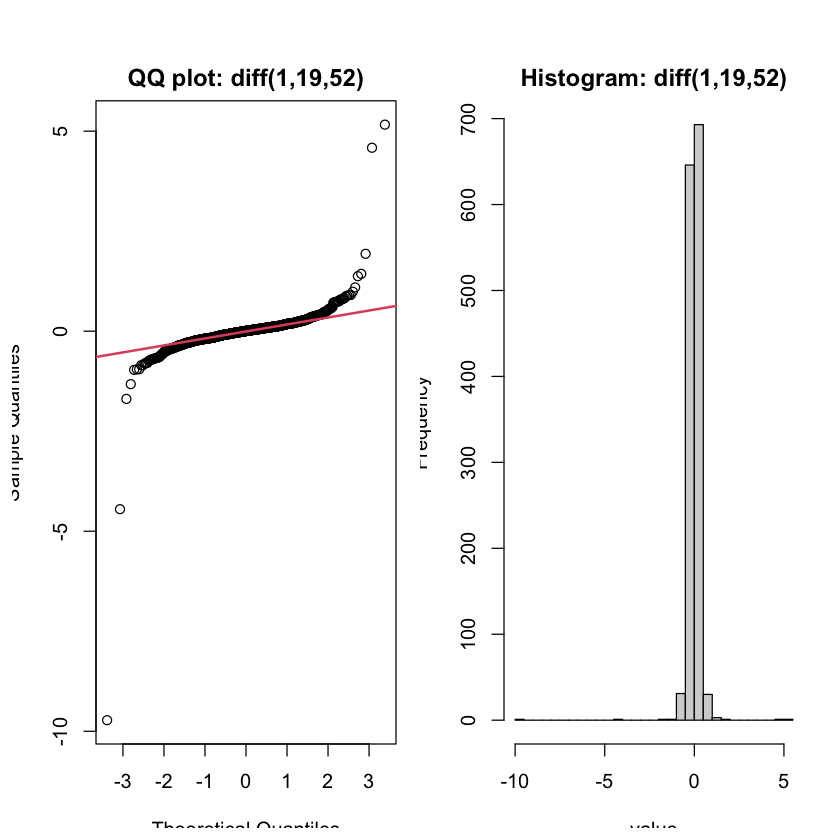

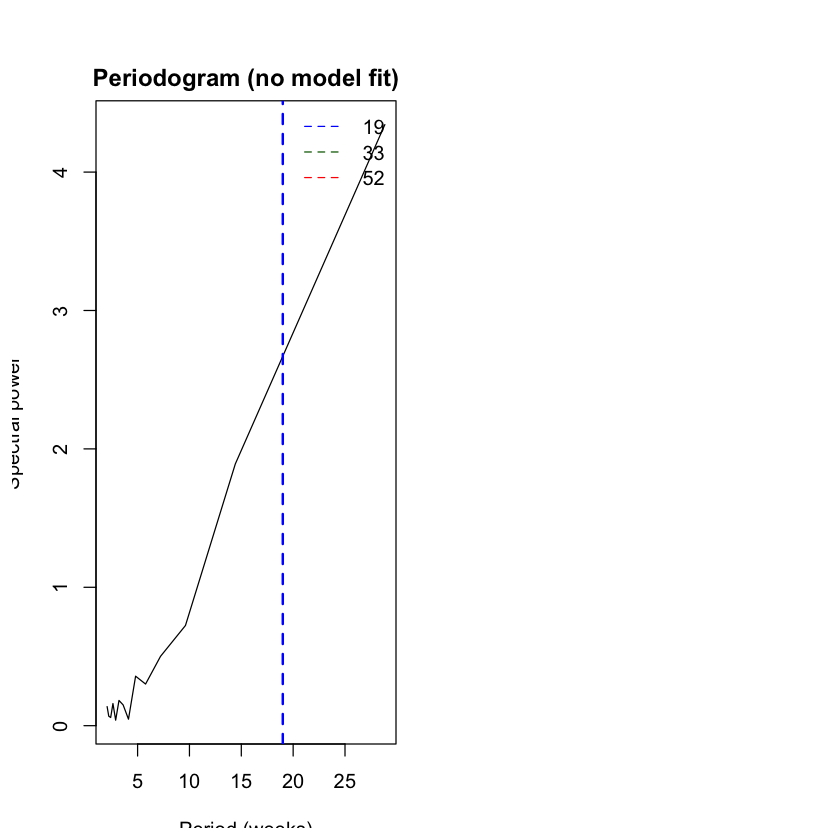

In [32]:
# Diagnostics-only: infer structure from ACF/PACF + FFT (no model fitting)
fdf <- read.csv("data/fluview_clean/ilinet_final.csv")
y <- as.numeric(fdf$age_0_4)
y_ts <- ts(y, frequency = 52)

# Candidate differencing views
d1 <- diff(y_ts, lag = 1)
d19 <- diff(y_ts, lag = 19)
d52 <- diff(y_ts, lag = 52)
d1_52 <- diff(d1, lag = 52)
d1_19_52 <- diff(diff(d1, lag = 19), lag = 52)

old_par <- par(no.readonly = TRUE)
on.exit(par(old_par))
par(mfrow = c(3, 2), mar = c(3, 3, 2, 1), oma = c(0.5, 0.5, 2.2, 0.5))

acf(d1, lag.max = 104, main = "ACF: diff(1)")
pacf(d1, lag.max = 104, main = "PACF: diff(1)")
acf(d1_52, lag.max = 104, main = "ACF: diff(1,52)")
pacf(d1_52, lag.max = 104, main = "PACF: diff(1,52)")
acf(d1_19_52, lag.max = 104, main = "ACF: diff(1,19,52)")
pacf(d1_19_52, lag.max = 104, main = "PACF: diff(1,19,52)")
mtext("Differencing diagnostics for lag selection", outer = TRUE, cex = 1.05)

# Residual-shape proxy after strongest differencing (QQ + histogram)
par(mfrow = c(1, 2), mar = c(3.5, 3.5, 2, 1))
qqnorm(as.numeric(d1_19_52), main = "QQ plot: diff(1,19,52)")
qqline(as.numeric(d1_19_52), col = 2, lwd = 2)
hist(as.numeric(d1_19_52), breaks = 40, main = "Histogram: diff(1,19,52)", xlab = "value")

# FFT / periodogram to find dominant periods without fitting
spec <- spectrum(y_ts, log = "no", plot = FALSE)
freq <- spec$freq
power <- spec$spec
period <- 1 / freq

# Keep interpretable periods only
keep <- which(period >= 2 & period <= 200 & is.finite(period) & is.finite(power))
ord <- order(power[keep], decreasing = TRUE)
top_k <- keep[ord[1:10]]

fft_table <- data.frame(
  period = round(period[top_k], 2),
  frequency = round(freq[top_k], 5),
  power = round(power[top_k], 4)
)
fft_table <- fft_table[order(fft_table$period), ]

cat("Top FFT periods (2..200):\n")
print(fft_table)

# Plot periodogram with reference lines at key periods
plot(period[keep], power[keep], type = "l",
     xlab = "Period (weeks)", ylab = "Spectral power",
     main = "Periodogram (no model fit)")
abline(v = c(19, 33, 52), col = c("blue", "darkgreen", "red"), lty = 2, lwd = 2)
legend("topright", legend = c("19", "33", "52"),
       col = c("blue", "darkgreen", "red"), lty = 2, bty = "n")

# Helpful numeric checks at specific lags from strongest differencing
acf_vals <- acf(d1_19_52, lag.max = 104, plot = FALSE)$acf[,1,1]
acf_lags <- acf(d1_19_52, lag.max = 104, plot = FALSE)$lag[,1,1] * frequency(y_ts)
idx <- function(k) which(round(acf_lags) == k)[1]

lag_report <- data.frame(
  lag = c(1, 2, 3, 19, 33, 52),
  acf = c(
    acf_vals[idx(1)], acf_vals[idx(2)], acf_vals[idx(3)],
    acf_vals[idx(19)], acf_vals[idx(33)], acf_vals[idx(52)]
  )
 )
cat("\nACF values after diff(1,19,52):\n")
print(lag_report)

  gap_id start end length
1      1    35  53     19
2      2    87 105     19
3      3   139 157     19
4      4   191 209     19
5      5   243 261     19
Using data after last detected gap: index 262 to 1482 
Observations after last gap: 1221 


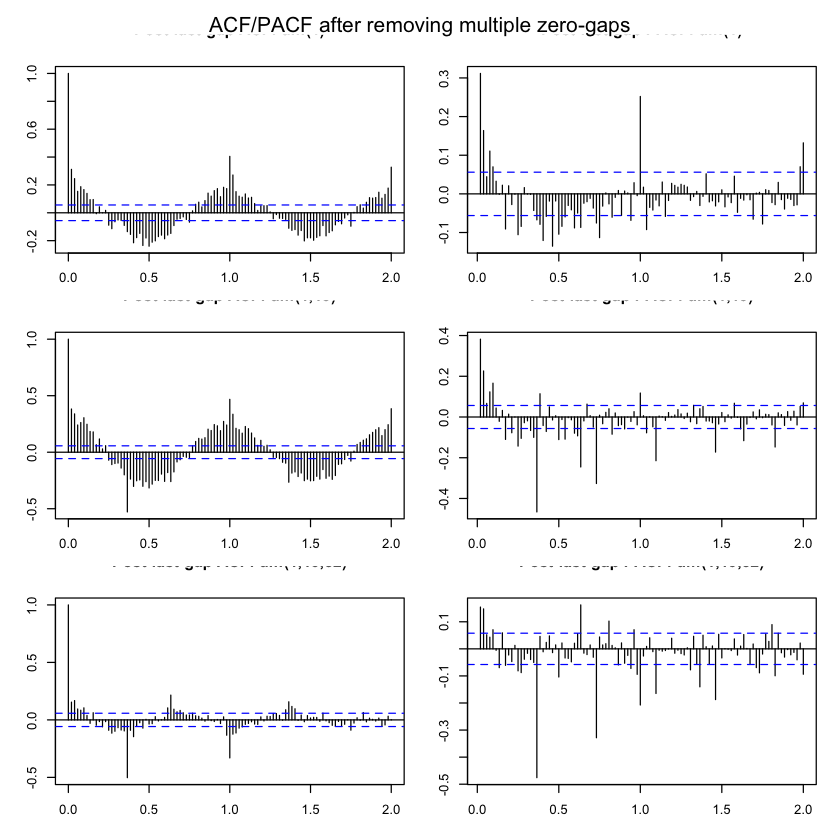

In [34]:
# Recompute ACF/PACF after accounting for multiple zero-collection gaps
fdf <- read.csv("data/fluview_clean/ilinet_final.csv")
y <- as.numeric(fdf$age_0_4)

# Detect consecutive zero-runs (0 on log1p scale means original count was 0)
is_zero <- y == 0
r <- rle(is_zero)
ends <- cumsum(r$lengths)
starts <- ends - r$lengths + 1
zero_runs <- which(r$values)

# Treat long zero runs as likely collection gaps
min_gap_len <- 10
gap_runs <- zero_runs[r$lengths[zero_runs] >= min_gap_len]

if (length(gap_runs) == 0) {
  cat("No long zero-gap detected; using full series.\n")
  start_after_gap <- 1
} else {
  gap_table <- data.frame(
    gap_id = seq_along(gap_runs),
    start = starts[gap_runs],
    end = ends[gap_runs],
    length = r$lengths[gap_runs]
  )
  print(gap_table)

  # Use data after the LAST detected gap to avoid both breaks
  last_gap <- tail(gap_runs, 1)
  start_after_gap <- ends[last_gap] + 1
  cat("Using data after last detected gap: index", start_after_gap, "to", length(y), "\n")
}

if (start_after_gap >= length(y)) stop("Last gap ends at/after final observation; no data left after gap.")

y_after <- y[start_after_gap:length(y)]
y_after_ts <- ts(y_after, frequency = 52)
cat("Observations after last gap:", length(y_after), "\n")

# ACF/PACF on post-last-gap series and key differenced versions
d1 <- diff(y_after_ts, lag = 1)
d1_19 <- diff(d1, lag = 19)
d1_52 <- diff(d1, lag = 52)
d1_19_52 <- diff(d1_19, lag = 52)

old_par <- par(no.readonly = TRUE)
on.exit(par(old_par))
par(mfrow = c(3, 2), mar = c(3, 3, 2, 1), oma = c(0.5, 0.5, 2.2, 0.5))

acf(d1, lag.max = 104, main = "Post-last-gap ACF: diff(1)")
pacf(d1, lag.max = 104, main = "Post-last-gap PACF: diff(1)")
acf(d1_19, lag.max = 104, main = "Post-last-gap ACF: diff(1,19)")
pacf(d1_19, lag.max = 104, main = "Post-last-gap PACF: diff(1,19)")
acf(d1_19_52, lag.max = 104, main = "Post-last-gap ACF: diff(1,19,52)")
pacf(d1_19_52, lag.max = 104, main = "Post-last-gap PACF: diff(1,19,52)")
mtext("ACF/PACF after removing multiple zero-gaps", outer = TRUE, cex = 1.05)

  segment start  end length
1       1     1   34     34
2       2    54   86     33
3       3   106  138     33
4       4   158  190     33
5       5   210  242     33
6       6   262 1482   1221


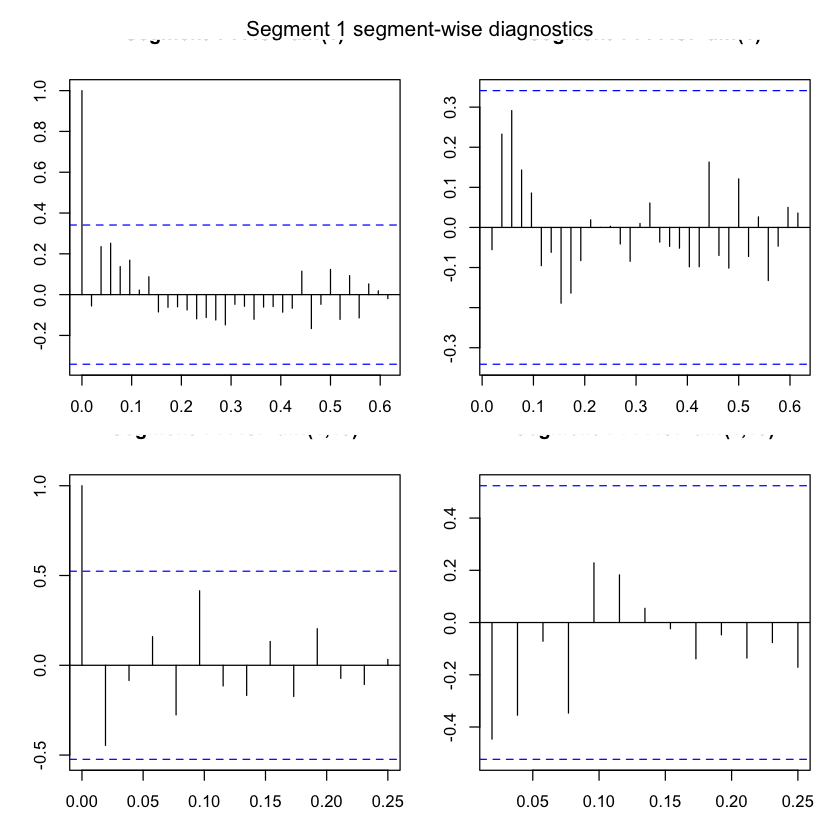

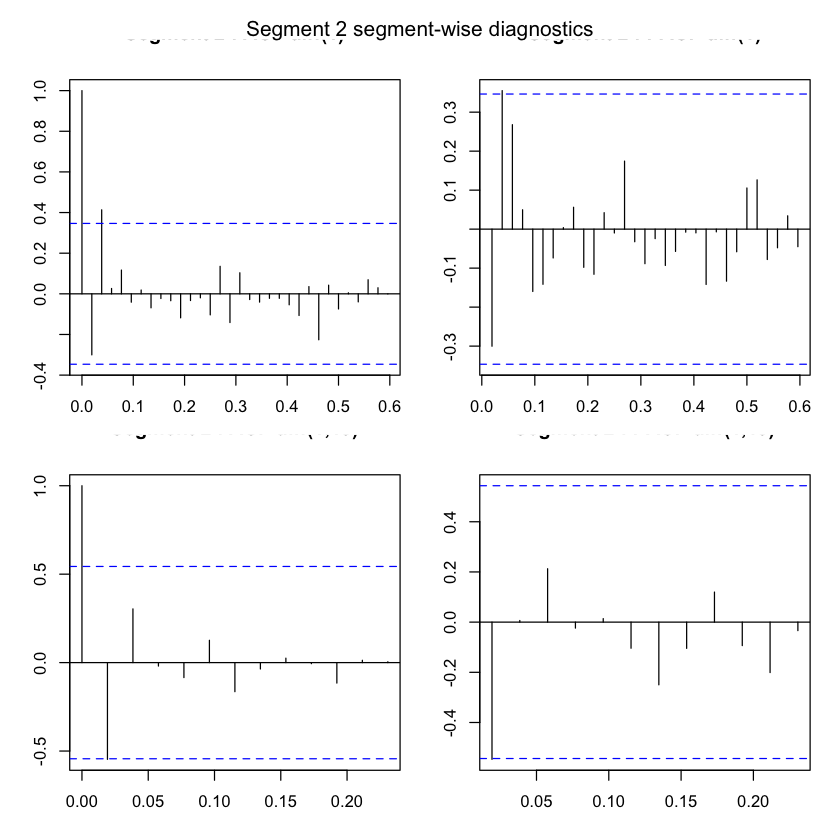

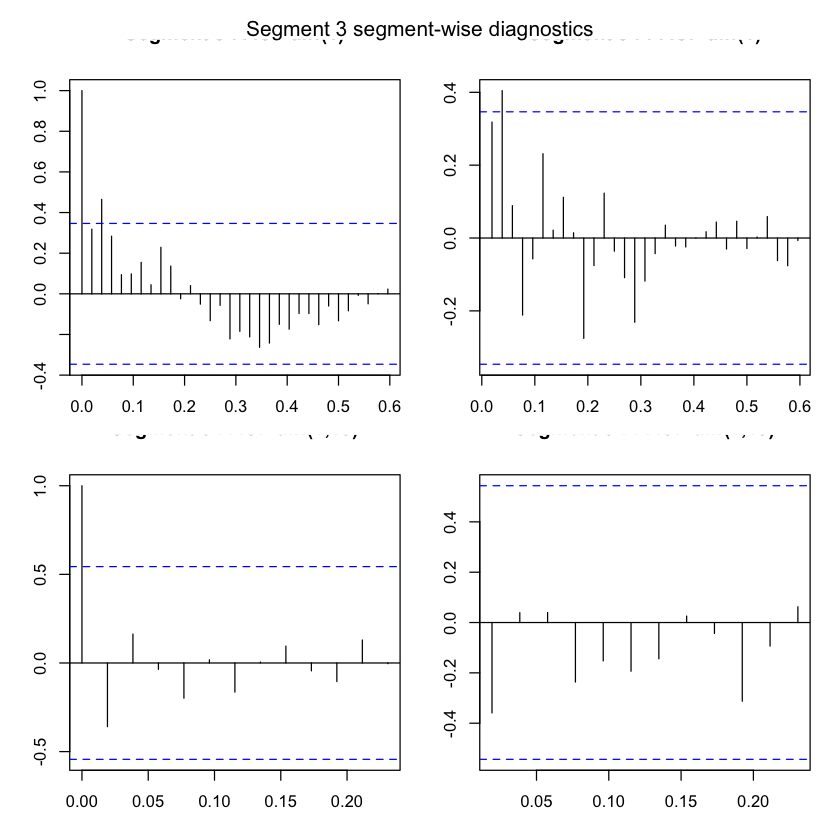

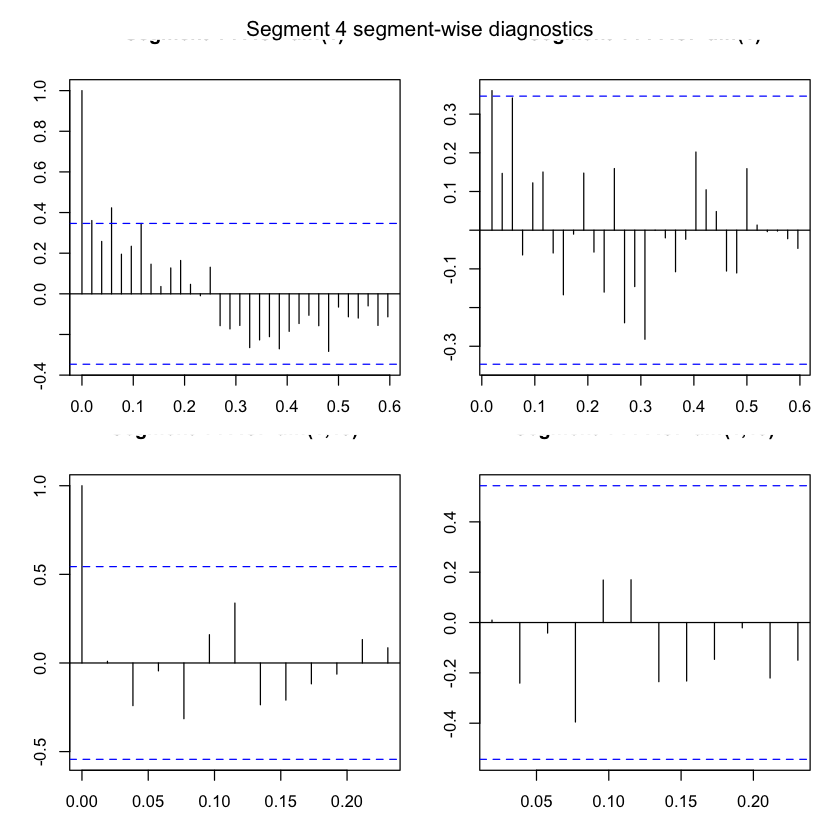

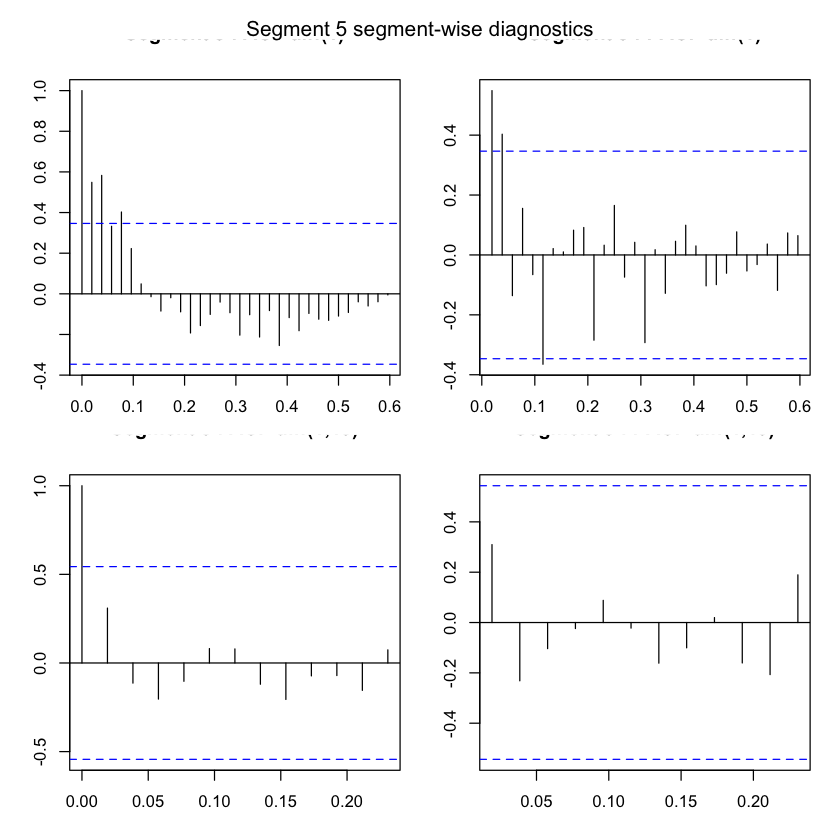

Lag-19 ACF by segment after diff(1,19):
  segment  lag19_acf
1       1         NA
2       2         NA
3       3         NA
4       4         NA
5       5         NA
6       6 -0.5281006


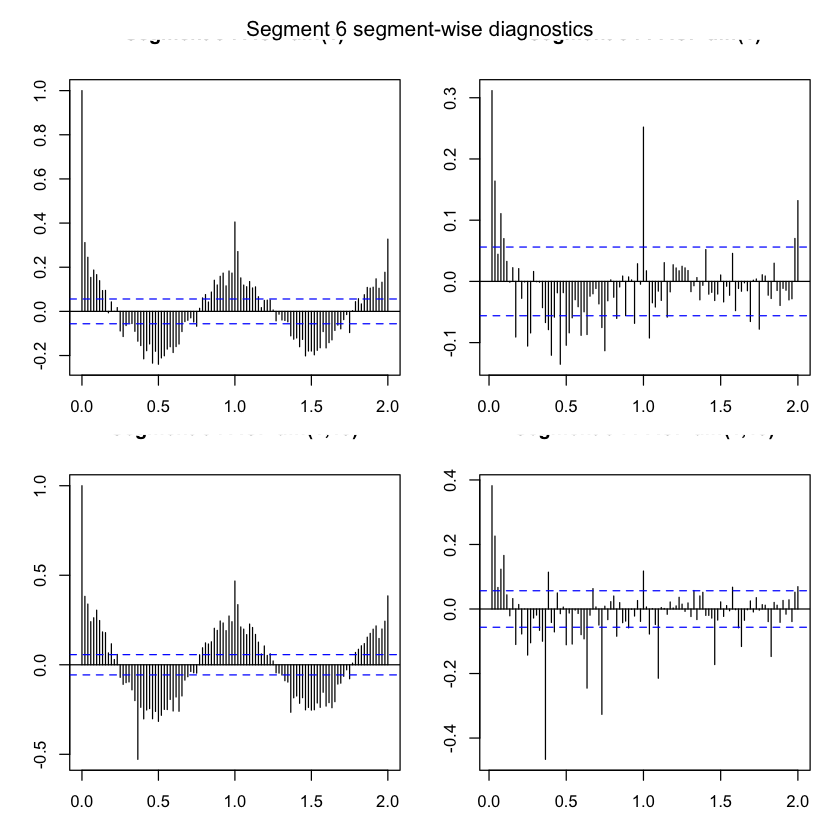

In [37]:
# Segment-wise ACF/PACF sanity check after removing zero-gaps
fdf <- read.csv("data/fluview_clean/ilinet_final.csv")
y <- as.numeric(fdf$age_0_4)

# Identify long zero-runs as gaps
is_zero <- y == 0
r <- rle(is_zero)
ends <- cumsum(r$lengths)
starts <- ends - r$lengths + 1
gap_runs <- which(r$values & r$lengths >= 10)

if (length(gap_runs) == 0) {
  cat("No long gaps found; using one full segment.\n")
  segments <- list(c(1, length(y)))
} else {
  # Build continuous non-gap segments between the detected gaps
  segments <- list()
  seg_start <- 1
  for (g in gap_runs) {
    seg_end <- starts[g] - 1
    if (seg_end >= seg_start) {
      segments[[length(segments) + 1]] <- c(seg_start, seg_end)
    }
    seg_start <- ends[g] + 1
  }
  if (seg_start <= length(y)) {
    segments[[length(segments) + 1]] <- c(seg_start, length(y))
  }
}

print(do.call(rbind, lapply(seq_along(segments), function(i) {
  data.frame(segment = i, start = segments[[i]][1], end = segments[[i]][2], length = segments[[i]][2] - segments[[i]][1] + 1)
})))

# Plot ACF/PACF for each segment separately
old_par <- par(no.readonly = TRUE)
on.exit(par(old_par))

for (i in seq_along(segments)) {
  idx <- segments[[i]][1]:segments[[i]][2]
  y_seg <- ts(y[idx], frequency = 52)

  if (length(y_seg) < 30) {
    cat("Skipping short segment", i, "(length < 30)\n")
    next
  }

  d1 <- diff(y_seg, lag = 1)
  d1_19 <- diff(d1, lag = 19)

  par(mfrow = c(2, 2), mar = c(3, 3, 2, 1), oma = c(0.5, 0.5, 2, 0.5))
  acf(d1, lag.max = 104, main = paste("Segment", i, ": ACF diff(1)"))
  pacf(d1, lag.max = 104, main = paste("Segment", i, ": PACF diff(1)"))
  acf(d1_19, lag.max = 104, main = paste("Segment", i, ": ACF diff(1,19)"))
  pacf(d1_19, lag.max = 104, main = paste("Segment", i, ": PACF diff(1,19)"))
  mtext(paste("Segment", i, "segment-wise diagnostics"), outer = TRUE, cex = 1.05)
}

# Numeric check: lag-19 autocorrelation in each segment after diff(1,19)
lag19_report <- do.call(rbind, lapply(seq_along(segments), function(i) {
  idx <- segments[[i]][1]:segments[[i]][2]
  y_seg <- ts(y[idx], frequency = 52)
  if (length(y_seg) < 30) return(NULL)
  d1_19 <- diff(diff(y_seg, lag = 1), lag = 19)
  acf_obj <- acf(d1_19, lag.max = 52, plot = FALSE)
  acf_vals <- acf_obj$acf[,1,1]
  acf_lags <- acf_obj$lag[,1,1] * frequency(y_seg)
  lag19_idx <- which(round(acf_lags) == 19)[1]
  data.frame(segment = i, lag19_acf = acf_vals[lag19_idx])
}))
cat("Lag-19 ACF by segment after diff(1,19):\n")
print(lag19_report)

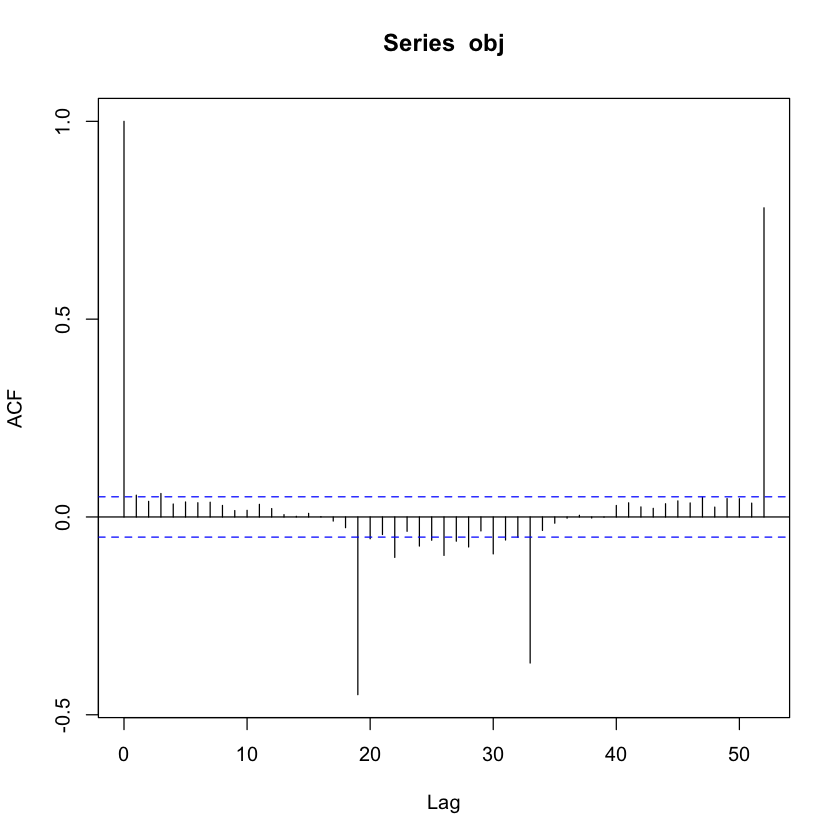

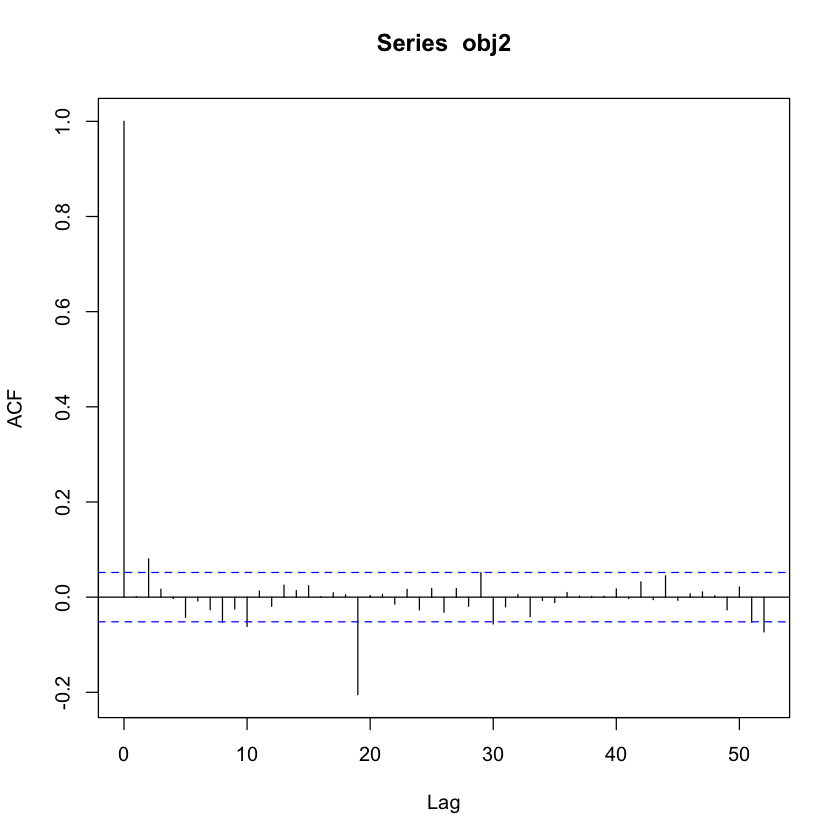

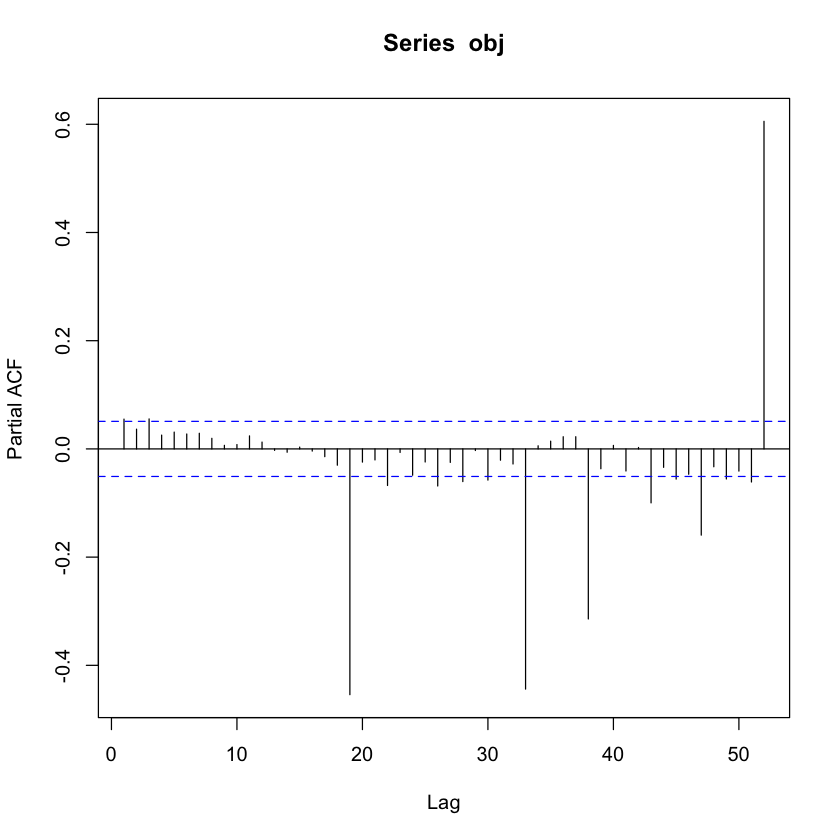

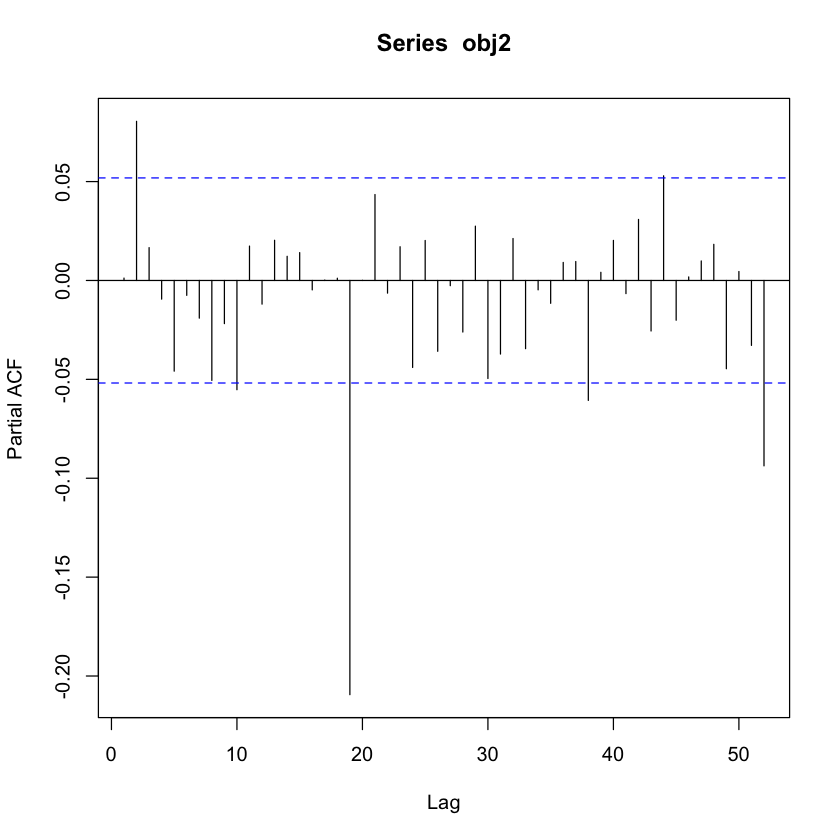

In [49]:
obj <- fdf$age_0_4
# fit  <- msarima(obj, orders = list(ar = c(1, 19), i = c(1, 52), ma = c(1, 19)), lags = c(1, 19, 52))
# rmse <- sqrt(mean(residuals(fit)^2, na.rm = TRUE))
# cat("In-sample RMSE for manual_111_lags_1_19_52:", round(rmse, 4), "\n")
obj <- diff(obj)
obj2 <- diff(obj,lag=52)
acf(obj,lag.max = 52)
acf(obj2,lag.max = 52)
pacf(obj,lag.max = 52)
pacf(obj2,lag.max = 52)

ERROR: Error in data.frame(p = p, q = q, P = P, Q = Q, aicc = aicc_val, bic = bic_val, : arguments imply differing number of rows: 1, 0


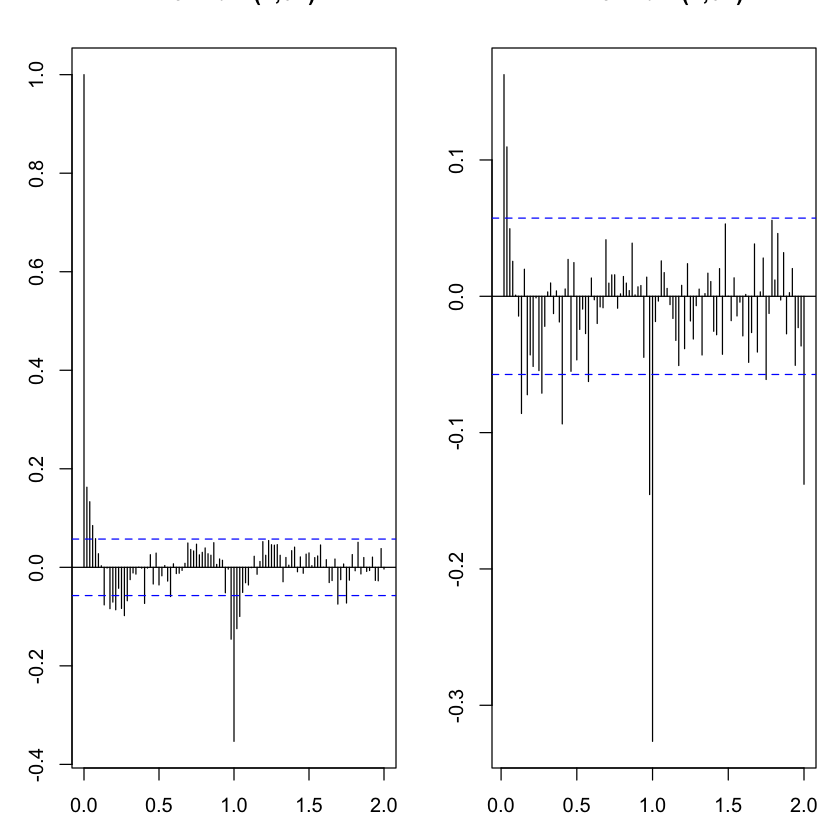

In [50]:
# Mixed seasonal msarima grid search: (p,1,q)(0,1,0)[52] with 19-week seasonal ARMA
library(smooth)

# Use the cleaned post-gap series if available; otherwise fall back to the full transformed series
series <- if (exists("y_after")) {
  as.numeric(y_after)
} else if (exists("y_after_ts")) {
  as.numeric(y_after_ts)
} else {
  y <- as.numeric(read.csv("data/fluview_clean/ilinet_final.csv")$age_0_4)
  y
}

series_ts <- ts(series, frequency = 52)

# Optional quick sanity check of the differenced series used by the model
d_1_52 <- diff(diff(series_ts, lag = 1), lag = 52)
par(mfrow = c(1, 2), mar = c(3, 3, 2, 1))
acf(d_1_52, lag.max = 104, main = "ACF: diff(1,52)")
pacf(d_1_52, lag.max = 104, main = "PACF: diff(1,52)")

# Model form we are searching over:
# (p,1,q)(0,1,0)[52](P,0,Q)[19]
# In msarima lag-order form this is approximated by:
#   lags = c(1, 19, 52)
#   ar   = c(p, P, 0)
#   i    = c(1, 0, 1)
#   ma   = c(q, Q, 0)

fit_mixed_msarima <- function(series, p, q, P, Q) {
  msarima(
    series,
    orders = list(
      ar = c(p, P, 0),
      i  = c(1, 0, 1),
      ma = c(q, Q, 0)
    ),
    lags = c(1, 19, 52)
  )
}

p_grid <- 0:2
q_grid <- 0:2
P_grid <- 0:2
Q_grid <- 0:2

results_mixed <- data.frame(
  p = integer(0),
  q = integer(0),
  P = integer(0),
  Q = integer(0),
  aicc = numeric(0),
  bic = numeric(0),
  loglik = numeric(0),
  stringsAsFactors = FALSE
)

fits_mixed <- list()

for (p in p_grid) {
  for (q in q_grid) {
    for (P in P_grid) {
      for (Q in Q_grid) {
        fit_obj <- tryCatch(fit_mixed_msarima(series, p, q, P, Q), error = function(e) NULL)
        if (is.null(fit_obj)) next

        fit_name <- paste0("p", p, "_q", q, "_P", P, "_Q", Q)
        ll <- tryCatch({
          if (!is.null(fit_obj$logLik)) as.numeric(fit_obj$logLik) else as.numeric(fit_obj$loglik)
        }, error = function(e) NA_real_)

        aicc_val <- tryCatch({
          ic <- fit_obj$ic
          if (!is.null(ic) && !is.null(ic["AICc"])) as.numeric(ic["AICc"]) else NA_real_
        }, error = function(e) NA_real_)

        bic_val <- tryCatch({
          ic <- fit_obj$ic
          if (!is.null(ic) && !is.null(ic["BIC"])) as.numeric(ic["BIC"]) else NA_real_
        }, error = function(e) NA_real_)

        if (is.na(aicc_val) || is.na(bic_val)) {
          aicc_val <- tryCatch(as.numeric(fit_obj$aicc), error = function(e) NA_real_)
          bic_val <- tryCatch(as.numeric(fit_obj$bic), error = function(e) NA_real_)
        }

        results_mixed <- rbind(results_mixed, data.frame(
          p = p, q = q, P = P, Q = Q,
          aicc = aicc_val, bic = bic_val, loglik = ll,
          stringsAsFactors = FALSE
        ))

        fits_mixed[[fit_name]] <- fit_obj
      }
    }
  }
}

results_mixed <- results_mixed[order(results_mixed$aicc), ]
print(results_mixed)

if (nrow(results_mixed) == 0) stop("No mixed msarima candidate converged.")

best_row <- results_mixed[1, ]
best_fit_name <- paste0("p", best_row$p, "_q", best_row$q, "_P", best_row$P, "_Q", best_row$Q)
best_fit_mixed <- fits_mixed[[best_fit_name]]

cat("\nBest mixed msarima by AICc:\n")
print(best_row)
print(best_fit_mixed)

# Residual diagnostics for the chosen mixed model
best_res <- tryCatch(as.numeric(residuals(best_fit_mixed)), error = function(e) as.numeric(best_fit_mixed$errors))
best_res <- best_res[is.finite(best_res)]

par(mfrow = c(2, 2), mar = c(3, 3, 2, 1))
acf(best_res, lag.max = 104, main = "Mixed-model residual ACF")
pacf(best_res, lag.max = 104, main = "Mixed-model residual PACF")
qqnorm(best_res, main = "Mixed-model residual QQ plot")
qqline(best_res, col = 2, lwd = 2)
hist(best_res, breaks = 30, main = "Mixed-model residual histogram", xlab = "Residual")

lb_mixed <- Box.test(best_res, lag = 24, type = "Ljung-Box")
print(lb_mixed)

best_fit_mixed

In [51]:
msarima(y, orders = list(ar=c(1,0,1), i=c(1,1,0), ma=c(0,0,0)),
        lags = c(1, 52, 19))
# (1,1,0)(0,1,0)_52 (1,0,0)_19

# Model 2: Add SMA at 19 (ACF spike there)
msarima(y, orders = list(ar=c(1,0,1), i=c(1,1,0), ma=c(0,0,1)),
        lags = c(1, 52, 19))
# (1,1,0)(0,1,0)_52 (1,0,1)_19

# Model 3: Add p=1 for the lag 1/2 in PACF
msarima(y, orders = list(ar=c(1,0,1), i=c(1,1,0), ma=c(1,0,1)),
        lags = c(1, 52, 19))
# (1,1,1)(0,1,0)_52 (1,0,1)_19

# Model 4: p=2 if lag 2 was prominent
msarima(y, orders = list(ar=c(2,0,1), i=c(1,1,0), ma=c(0,0,1)),
        lags = c(1, 52, 19))

Time elapsed: 0.53 seconds
Model estimated using msarima() function: SARIMA(1,1,0)[1](0,1,0)[52](1,0,0)[19]
With backcasting initialisation
Distribution assumed in the model: Normal
Loss function type: likelihood; Loss function value: 1365.153
ARMA parameters of the model:
        Lag 1 Lag 19
AR(1) -0.0775 0.3518

Sample size: 1482
Number of estimated parameters: 3
Number of degrees of freedom: 1479
Information criteria:
     AIC     AICc      BIC     BICc 
2736.307 2736.323 2752.210 2752.269 

Time elapsed: 0.6 seconds
Model estimated using msarima() function: SARIMA(1,1,0)[1](0,1,0)[52](1,0,1)[19]
With backcasting initialisation
Distribution assumed in the model: Normal
Loss function type: likelihood; Loss function value: 654.1723
ARMA parameters of the model:
        Lag 1 Lag 19
AR(1) -0.0135 0.3346
       Lag 19
MA(1) -0.9429

Sample size: 1482
Number of estimated parameters: 4
Number of degrees of freedom: 1478
Information criteria:
     AIC     AICc      BIC     BICc 
1316.345 1316.372 1337.549 1337.648 

Time elapsed: 0.63 seconds
Model estimated using msarima() function: SARIMA(1,1,1)[1](0,1,0)[52](1,0,1)[19]
With backcasting initialisation
Distribution assumed in the model: Normal
Loss function type: likelihood; Loss function value: 609.9269
ARMA parameters of the model:
        Lag 1 Lag 19
AR(1) -0.6174 0.3384
       Lag 1  Lag 19
MA(1) 0.6511 -0.9755

Sample size: 1482
Number of estimated parameters: 5
Number of degrees of freedom: 1477
Information criteria:
     AIC     AICc      BIC     BICc 
1229.854 1229.895 1256.360 1256.508 

Time elapsed: 0.91 seconds
Model estimated using msarima() function: SARIMA(2,1,0)[1](0,1,0)[52](1,0,1)[19]
With backcasting initialisation
Distribution assumed in the model: Normal
Loss function type: likelihood; Loss function value: 667.5751
ARMA parameters of the model:
        Lag 1 Lag 19
AR(1) -0.0357 0.2814
AR(2)  0.0655     NA
       Lag 19
MA(1) -0.9823

Sample size: 1482
Number of estimated parameters: 5
Number of degrees of freedom: 1477
Information criteria:
     AIC     AICc      BIC     BICc 
1345.150 1345.191 1371.656 1371.804 

Time elapsed: 2.45 seconds
Model estimated using msarima() function: SARIMA(1,1,1)[1](1,1,1)[19](1,1,1)[52]
With backcasting initialisation
Distribution assumed in the model: Normal
Loss function type: likelihood; Loss function value: 1322.837
ARMA parameters of the model:
       Lag 1  Lag 19  Lag 52
AR(1) -0.485 -0.6451 -0.4801
       Lag 1  Lag 19  Lag 52
MA(1) 0.3419 -0.9292 -0.9852

Sample size: 1482
Number of estimated parameters: 7
Number of degrees of freedom: 1475
Information criteria:
     AIC     AICc      BIC     BICc 
2659.674 2659.750 2696.782 2697.060 

In-sample RMSE for manual_111_lags_1_19_52 0.5908 
In-sample RMSE for manual_111_lags_1_19_52: 0.3652 


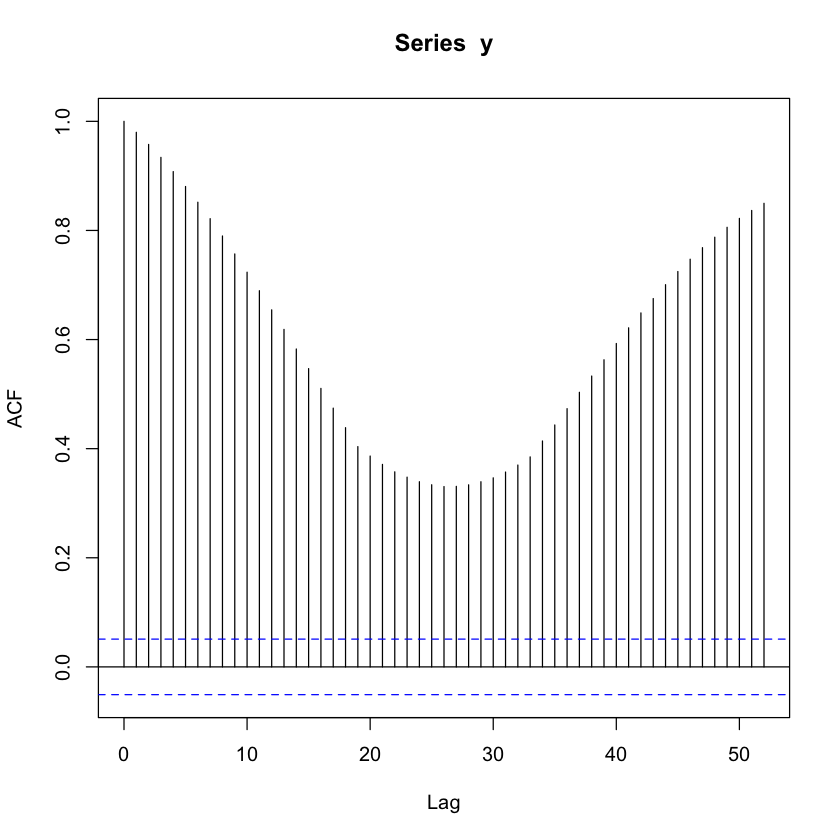

In [ ]:

acf(y,lag.max = 52)
fit_train0 <- msarima(
  y,
  orders = list(ar = c(1, 1,1), i = c(1, 1,1), ma = c(1, 1,1)),
  lags = c(1, 19, 52)
)
fit_train0
rmse <- sqrt(mean(residuals(fit_train0)^2, na.rm = TRUE))/max(y)
cat("In-sample RMSE for manual_111_lags_1_19_52",round(rmse, 4), "\n")
# let us perturb this model to see if we can do better?

mod <- msarima(y, orders = list(ar=c(1,0,1), i=c(1,1,0), ma=c(1,0,1)),
        lags = c(1, 52, 19))
rmse <- sqrt(mean(residuals(mod)^2, na.rm = TRUE))/max(y)
cat("In-sample RMSE for manual_111_lags_1_19_52:", round(rmse, 4), "\n")    